In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator as plot_creator
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
comparer_lime_k = plot_creator.Comparer("LIME Adult k-anonymity", "../data/adult/lime/k_anonymity", ascending=True)
comparer_lime_t = plot_creator.Comparer("LIME Adult t-closeness", "../data/adult/lime/t_closeness")

comparer_shap_k = plot_creator.Comparer("SHAP Adult k-anonymity", "../data/adult/shap/k_anonymity", ascending=True)
comparer_shap_t = plot_creator.Comparer("SHAP Adult t-closeness", "../data/adult/shap/t_closeness")

Note, in the following "LIME" plots, not all the features occur for every dataset. This happens because the submodular pick method from the LIME paper makes 1000 local explanations that try to explain data points which are representative for the entire dataset, and each explanation only look at the 5 most important features. The "total" importance for the features in a dataset for a model has been determined by summing all the linear weights associated with a feature in the linear model created by LIME (interpreted as the feature contribution). For some datasets local explainable models for different datapoints find different features important, making the total number of important feature higher, compared to highly anonymized datasets where the same select few feature might be importatn for all the representative 1000 local explanations

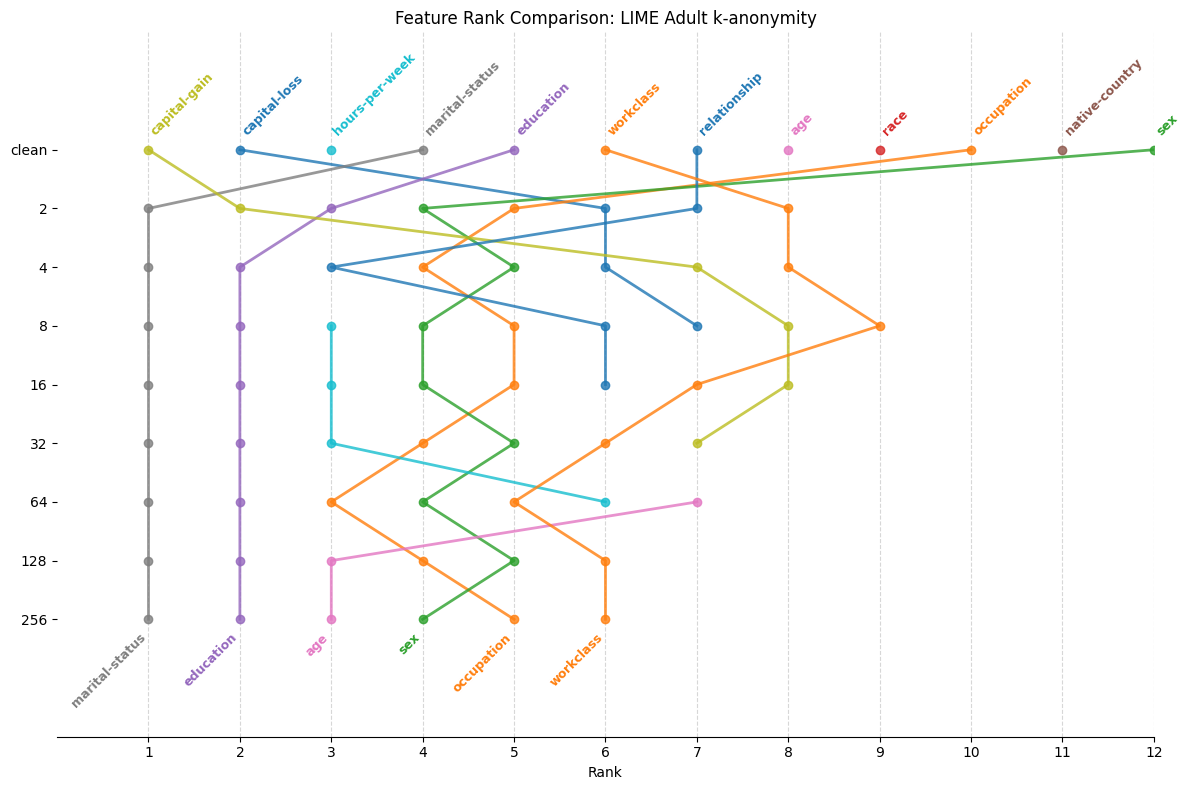

In [5]:
comparer_lime_k.plot_line()

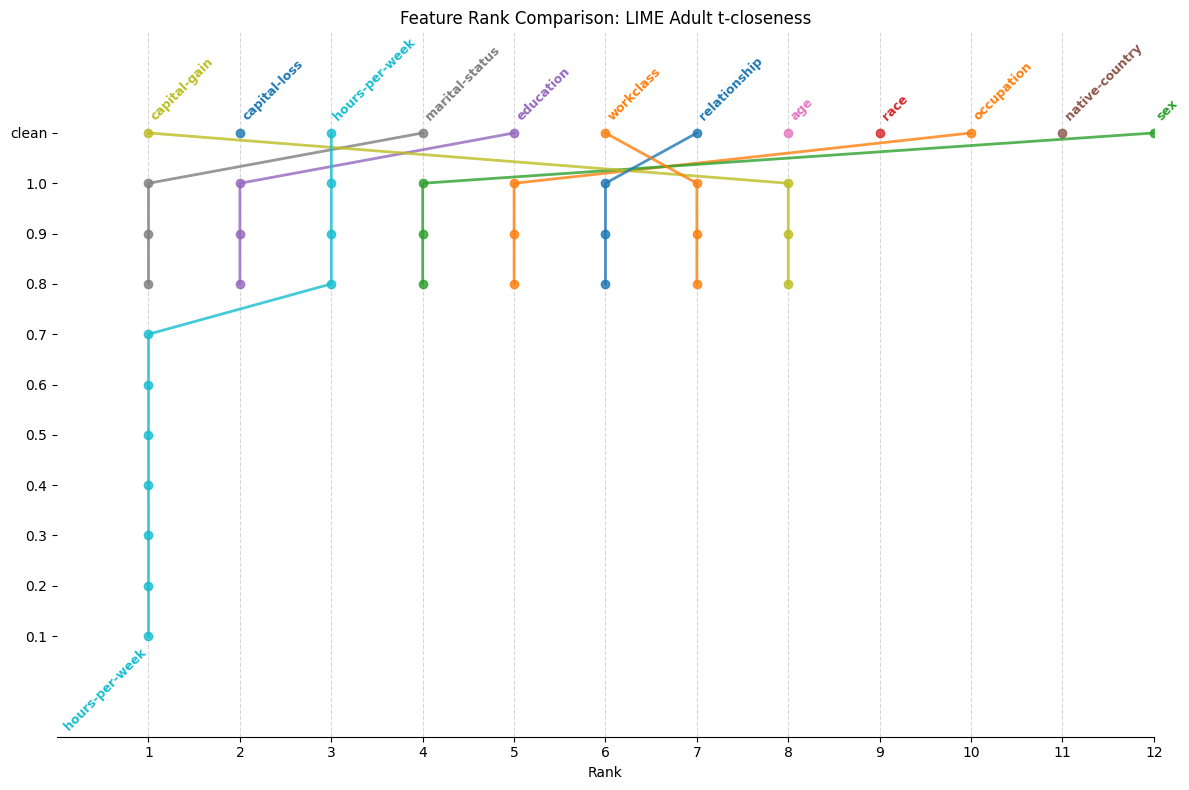

In [6]:
comparer_lime_t.plot_line()

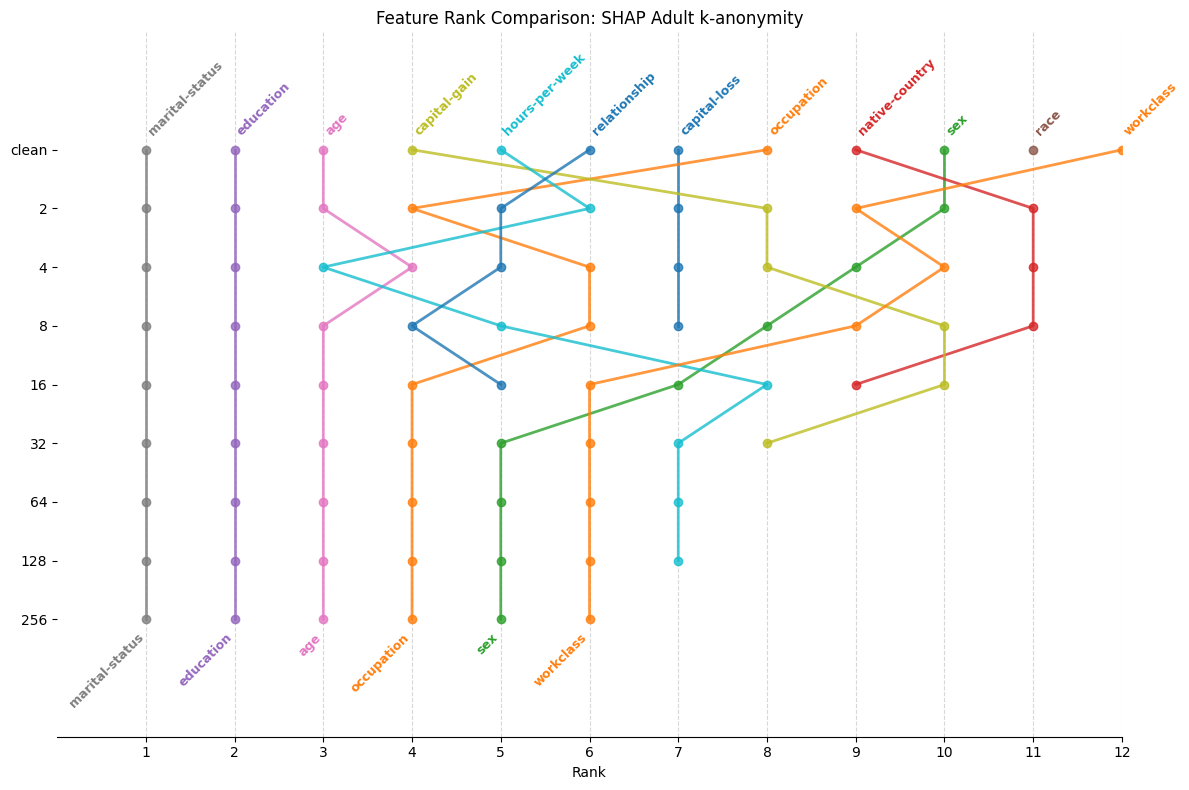

In [7]:
comparer_shap_k.plot_line()

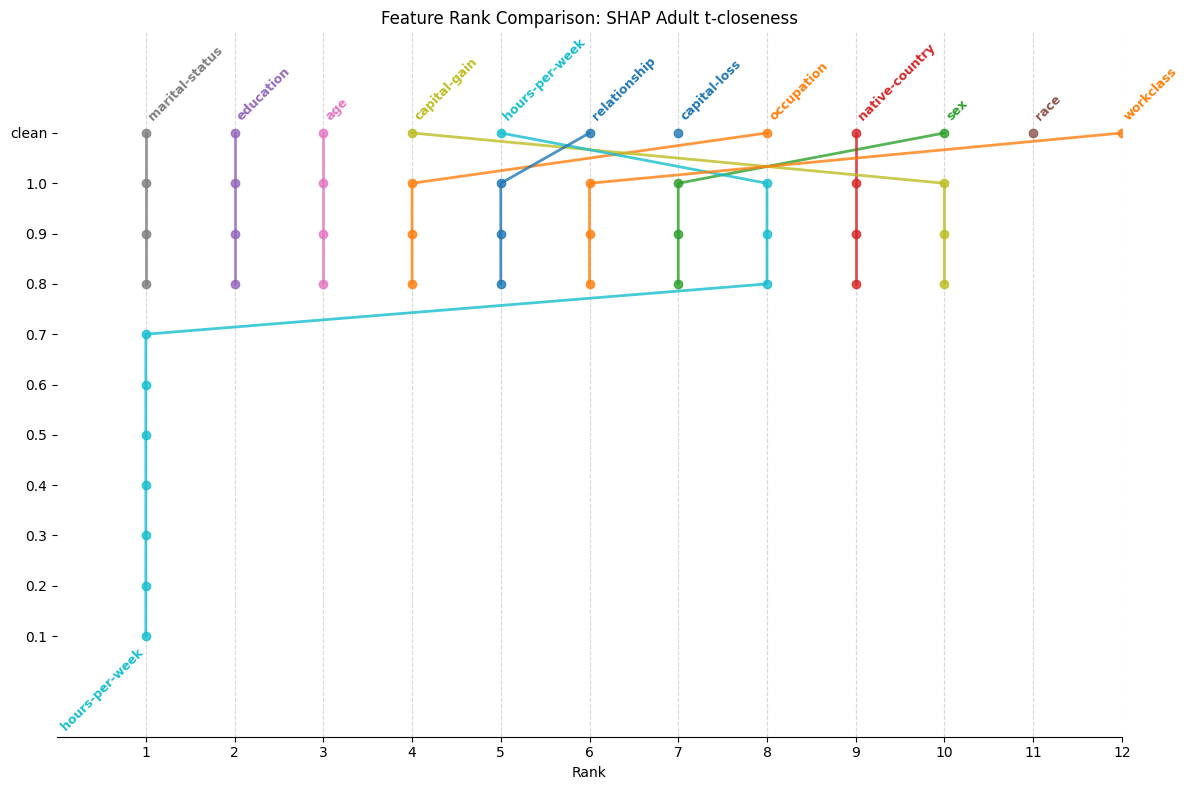

In [8]:
comparer_shap_t.plot_line()

Now how come that the even for SHAP not all features contribute? Simple. The features that are no longer included in more animyzed datasets have either been suppressed completely. Some features are not suppresed completely (replaced by a '*'), but they are generalized to such an extent that the feature has the same value for all instances. This often happens in the numeric features which has been discretized into even ranges. The outliers have then been supressed by the anyana anonymization library

The p-value of the kendaltau statistic is the p value for the null hypothesis: *The rank correlation is zero*. If the rank correlation is zero, the two rankings are independent, i.e. they are rather random compared to one another, and the do not correlate with one another at all. Low p-values indicate that the alternative hypothesis is true, i.e. *the rank correlation is nonzero*, meaning the two rankings are similar. Note, it is a two sided hypothesis test, so we are investigating if there is a positive or a negative correlation between the two orderings. 

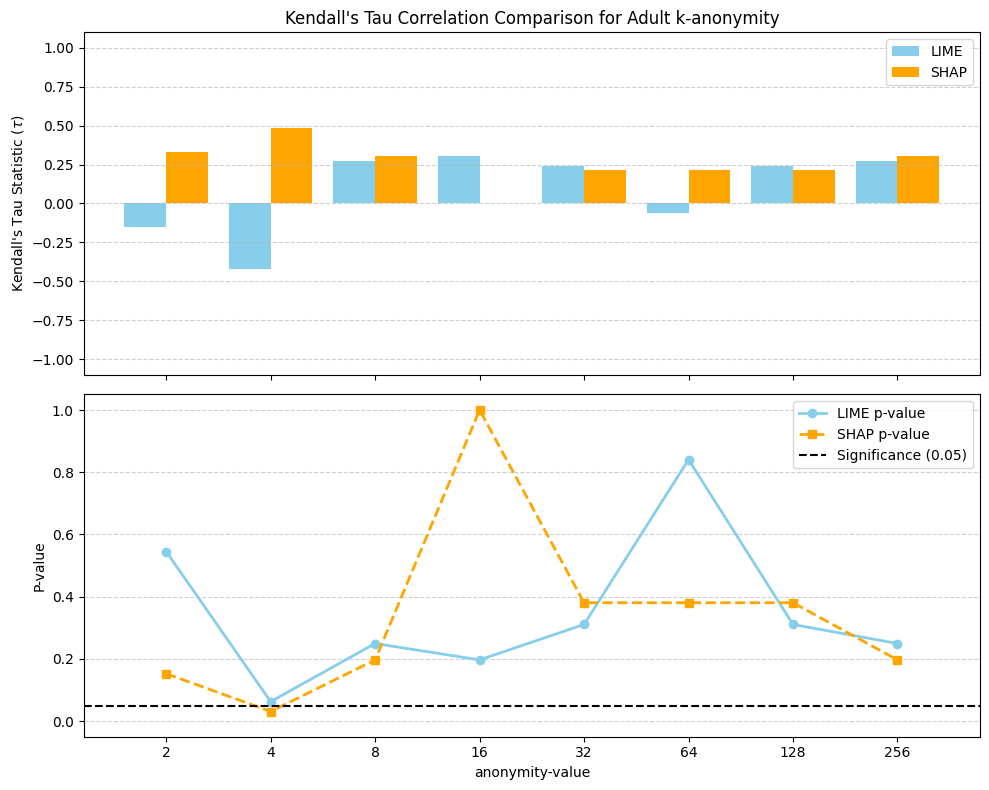

In [9]:
plot_creator.plot_comparison(
    [comparer_lime_k, comparer_shap_k],
    ["LIME", "SHAP"],
    "Adult k-anonymity"
)

In `k_anonymity` there are more differences between the different datasets. Different levels of hiearchies have been applied to each layer. It also makes the importance of the vectors more all over the place

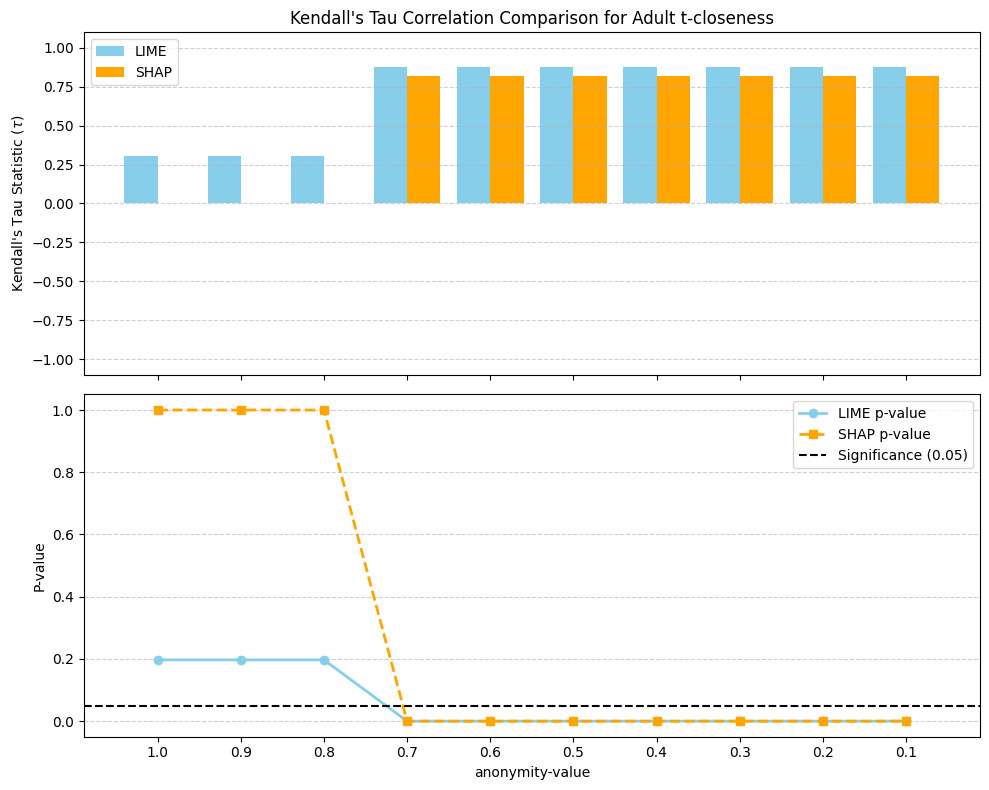

In [10]:
plot_creator.plot_comparison(
    [comparer_lime_t, comparer_shap_t],
    ["LIME", "SHAP"],
    "Adult t-closeness"
)

in `t_closeness` there is two big changes in the anonymizaiton structure. One between clean and 1.0 and one between 0.8 and 0.7. This is also clearly seen in the data $he$